# Medical Insurance Risk Prediction
In this notebook, we develop machine learning models to classify individuals into different medical risk levels based on demographic, lifestyle, and clinical features. Two risk-stratification approaches are explored: a three-class model (low, medium, high) and a simplified binary model (low vs. high). By comparing their performance and interpretability, we aim to determine which classification method provides the most practical value for healthcare screening and early-risk detection.



---


#### Sebastian HUARACA LAPA
#### Nicole VERZA DOS SANTOS


---





## Importation


In [69]:

# ----------------------------
# DATA MANIPULATION
# ----------------------------
import pandas as pd
import numpy as np

# ----------------------------
# DATA VISUALIZATION
# ----------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# ----------------------------
# STATISTICAL TESTS
# ----------------------------
from scipy.stats import chi2_contingency, f_oneway, kruskal

# ----------------------------
# MACHINE LEARNING
# ----------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

## Dataset

In [159]:
url = "https://raw.githubusercontent.com/Sebasss-h/Medical-Insurance-Risk-Classification-using-Machine-Learning/refs/heads/main/Data/medical_insurance.csv"
df = pd.read_csv(url)
df

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,...,0,0,0,0,0,1,0,0,0,0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,0,0,0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,...,0,0,0,1,0,1,0,0,0,0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,...,0,0,1,0,0,2,2,1,0,0


## Descriptive analysis


In [160]:
print("Dataset dimensions:", df.shape)
print("\nData types:")
print(df.dtypes)

Dataset dimensions: (100000, 54)

Data types:
person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                         float64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
bmi                            float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible        

In [161]:
df=df.drop('person_id',axis=1)

In [162]:
num_vars = df.select_dtypes(include=['number']).columns
cat_vars = df.select_dtypes(exclude=['number']).columns

print("Numerical variables:", len(num_vars), "\n", list(num_vars))
print("\nCategorical variables:", len(cat_vars), "\n", list(cat_vars))

Numerical variables: 43 
 ['age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']

Categorical variables: 10 
 ['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier']


In [163]:
print("NaN or missing data:")
print(df.isnull().sum())

NaN or missing data:
age                                0
sex                                0
region                             0
urban_rural                        0
income                             0
education                          0
marital_status                     0
employment_status                  0
household_size                     0
dependents                         0
bmi                                0
smoker                             0
alcohol_freq                   30083
visits_last_year                   0
hospitalizations_last_3yrs         0
days_hospitalized_last_3yrs        0
medication_count                   0
systolic_bp                        0
diastolic_bp                       0
ldl                                0
hba1c                              0
plan_type                          0
network_tier                       0
deductible                         0
copay                              0
policy_term_years                  0
policy_changes_la

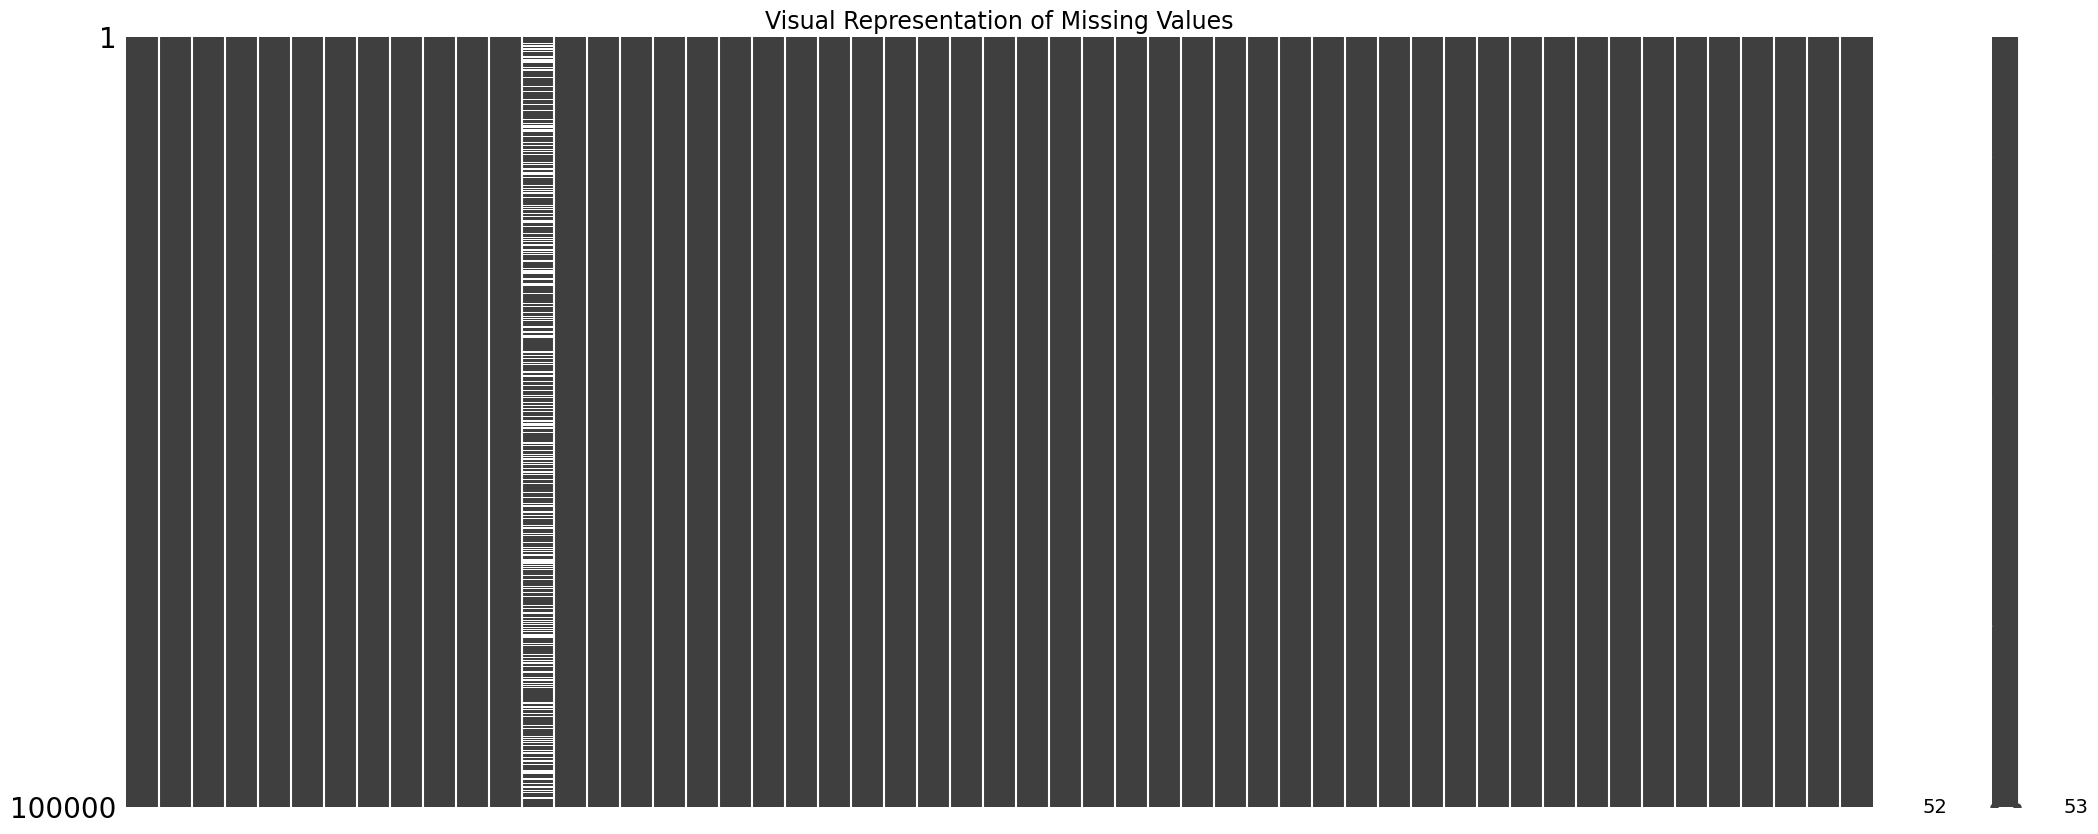

In [164]:
msno.matrix(df)
plt.title("Visual Representation of Missing Values", fontsize=17)
plt.show()

In [165]:
df['alcohol_freq'].unique()

array([nan, 'Weekly', 'Daily', 'Occasional'], dtype=object)

In [166]:
df_nan_alcohol_freq = df[df['alcohol_freq'].isna()].copy()
chronic_cols = [
    'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease',
    'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health'
]
df_nan_alcohol_freq['chronic_count'] = df_nan_alcohol_freq[chronic_cols].sum(axis=1)

df_nan_alcohol_freq['chronic_count'].describe()

,chronic_count
count,30083.000000
mean,0.722102
std,0.803861
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,5.000000


The missing values in alcohol_freq correspond to individuals who are generally healthy (average number of chronic diseases = 0.72); therefore, we classify them as ‘Never’.

In [167]:
df['alcohol_freq']=df['alcohol_freq'].fillna('Never')

In [168]:
print("NaN or missing data:")
print(df.isnull().sum())

NaN or missing data:
age                            0
sex                            0
region                         0
urban_rural                    0
income                         0
education                      0
marital_status                 0
employment_status              0
household_size                 0
dependents                     0
bmi                            0
smoker                         0
alcohol_freq                   0
visits_last_year               0
hospitalizations_last_3yrs     0
days_hospitalized_last_3yrs    0
medication_count               0
systolic_bp                    0
diastolic_bp                   0
ldl                            0
hba1c                          0
plan_type                      0
network_tier                   0
deductible                     0
copay                          0
policy_term_years              0
policy_changes_last_2yrs       0
provider_quality               0
risk_score                     0
annual_medical_cost   

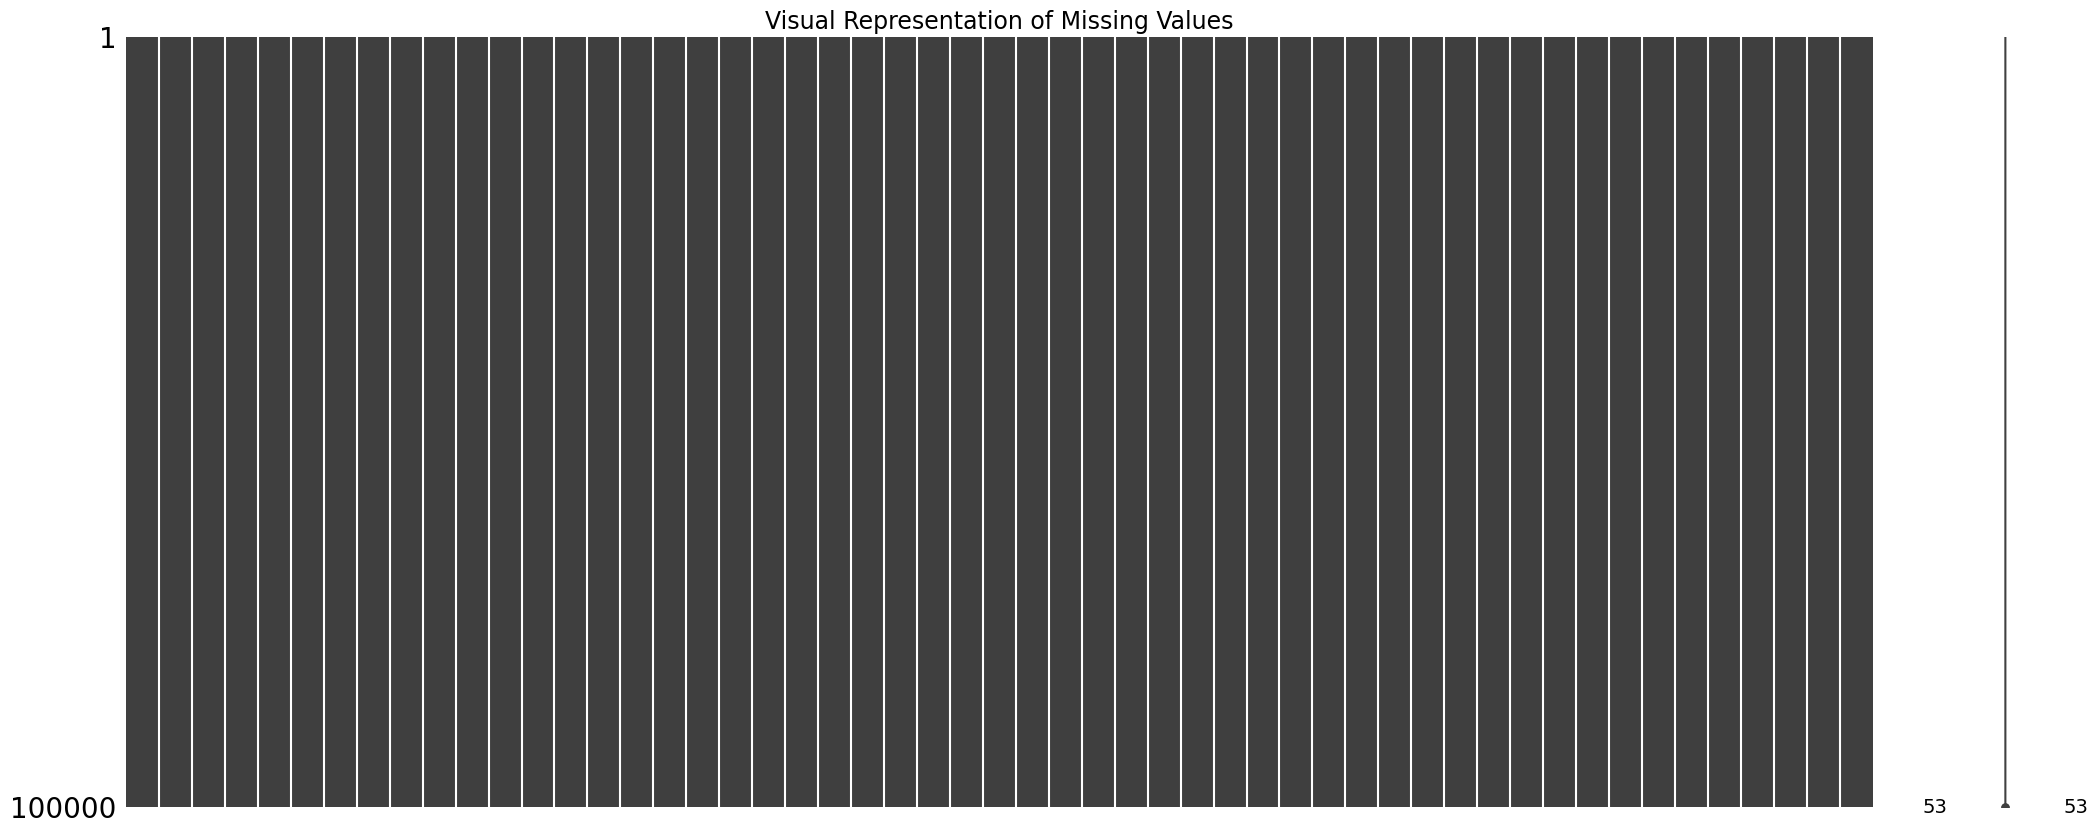

In [169]:
msno.matrix(df)
plt.title("Visual Representation of Missing Values", fontsize=17)
plt.show()

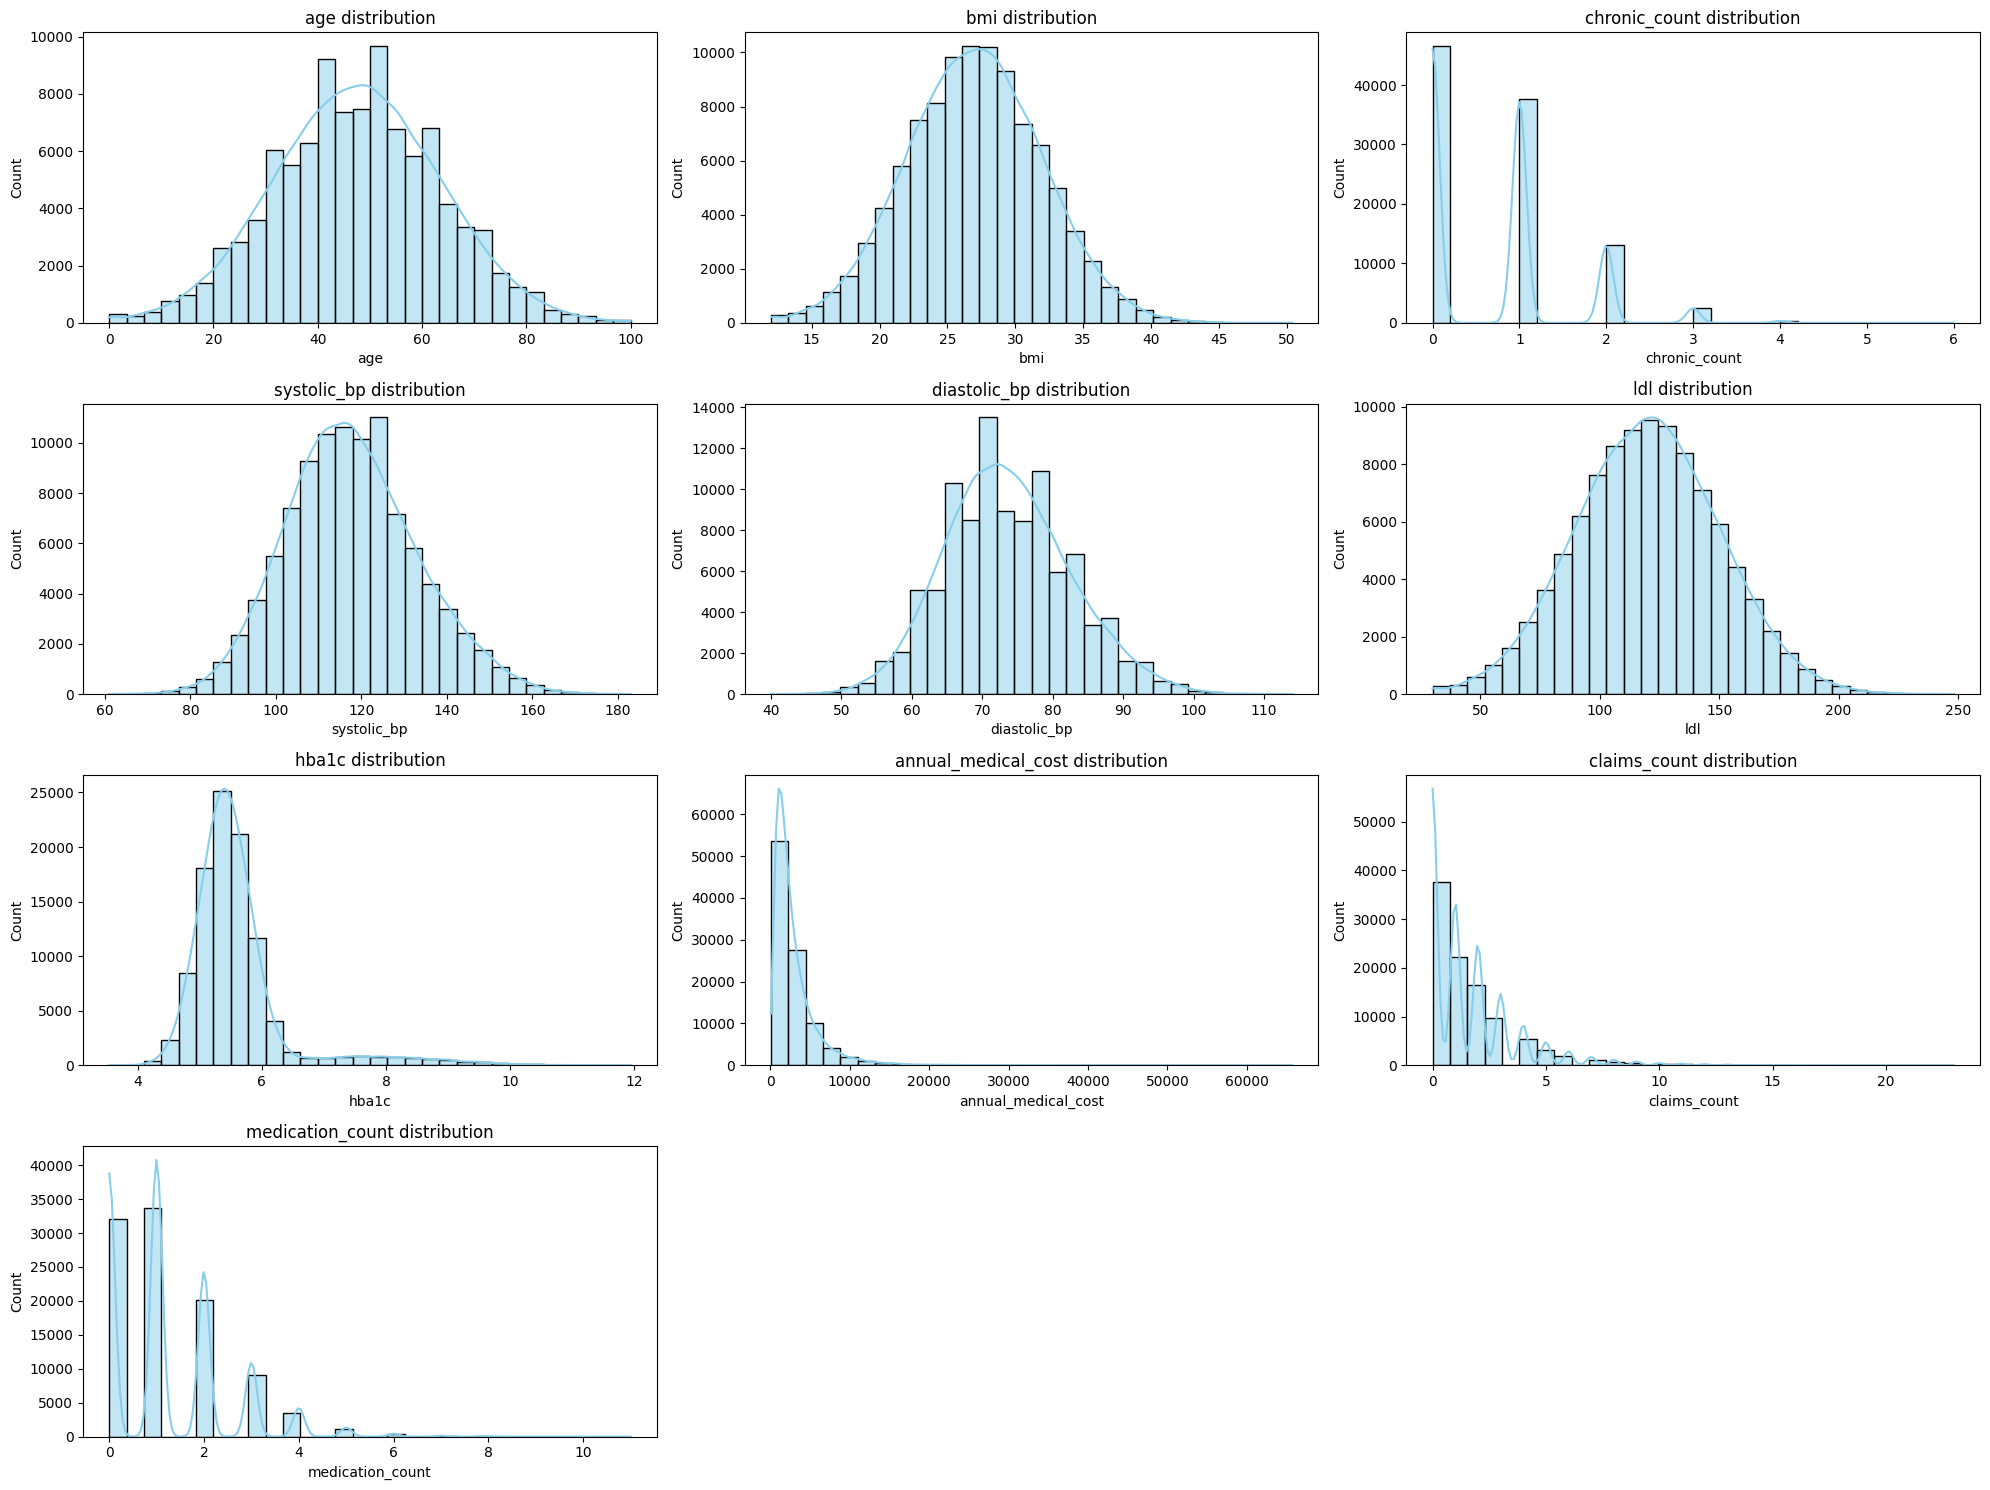

In [170]:
num_cols = ['age','bmi','chronic_count','systolic_bp','diastolic_bp','ldl','hba1c','annual_medical_cost','claims_count','medication_count']

plt.figure(figsize=(20,15))
for i, col in enumerate(num_cols):
    plt.subplot(4,3,i+1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col} distribution')
plt.tight_layout()
plt.show()

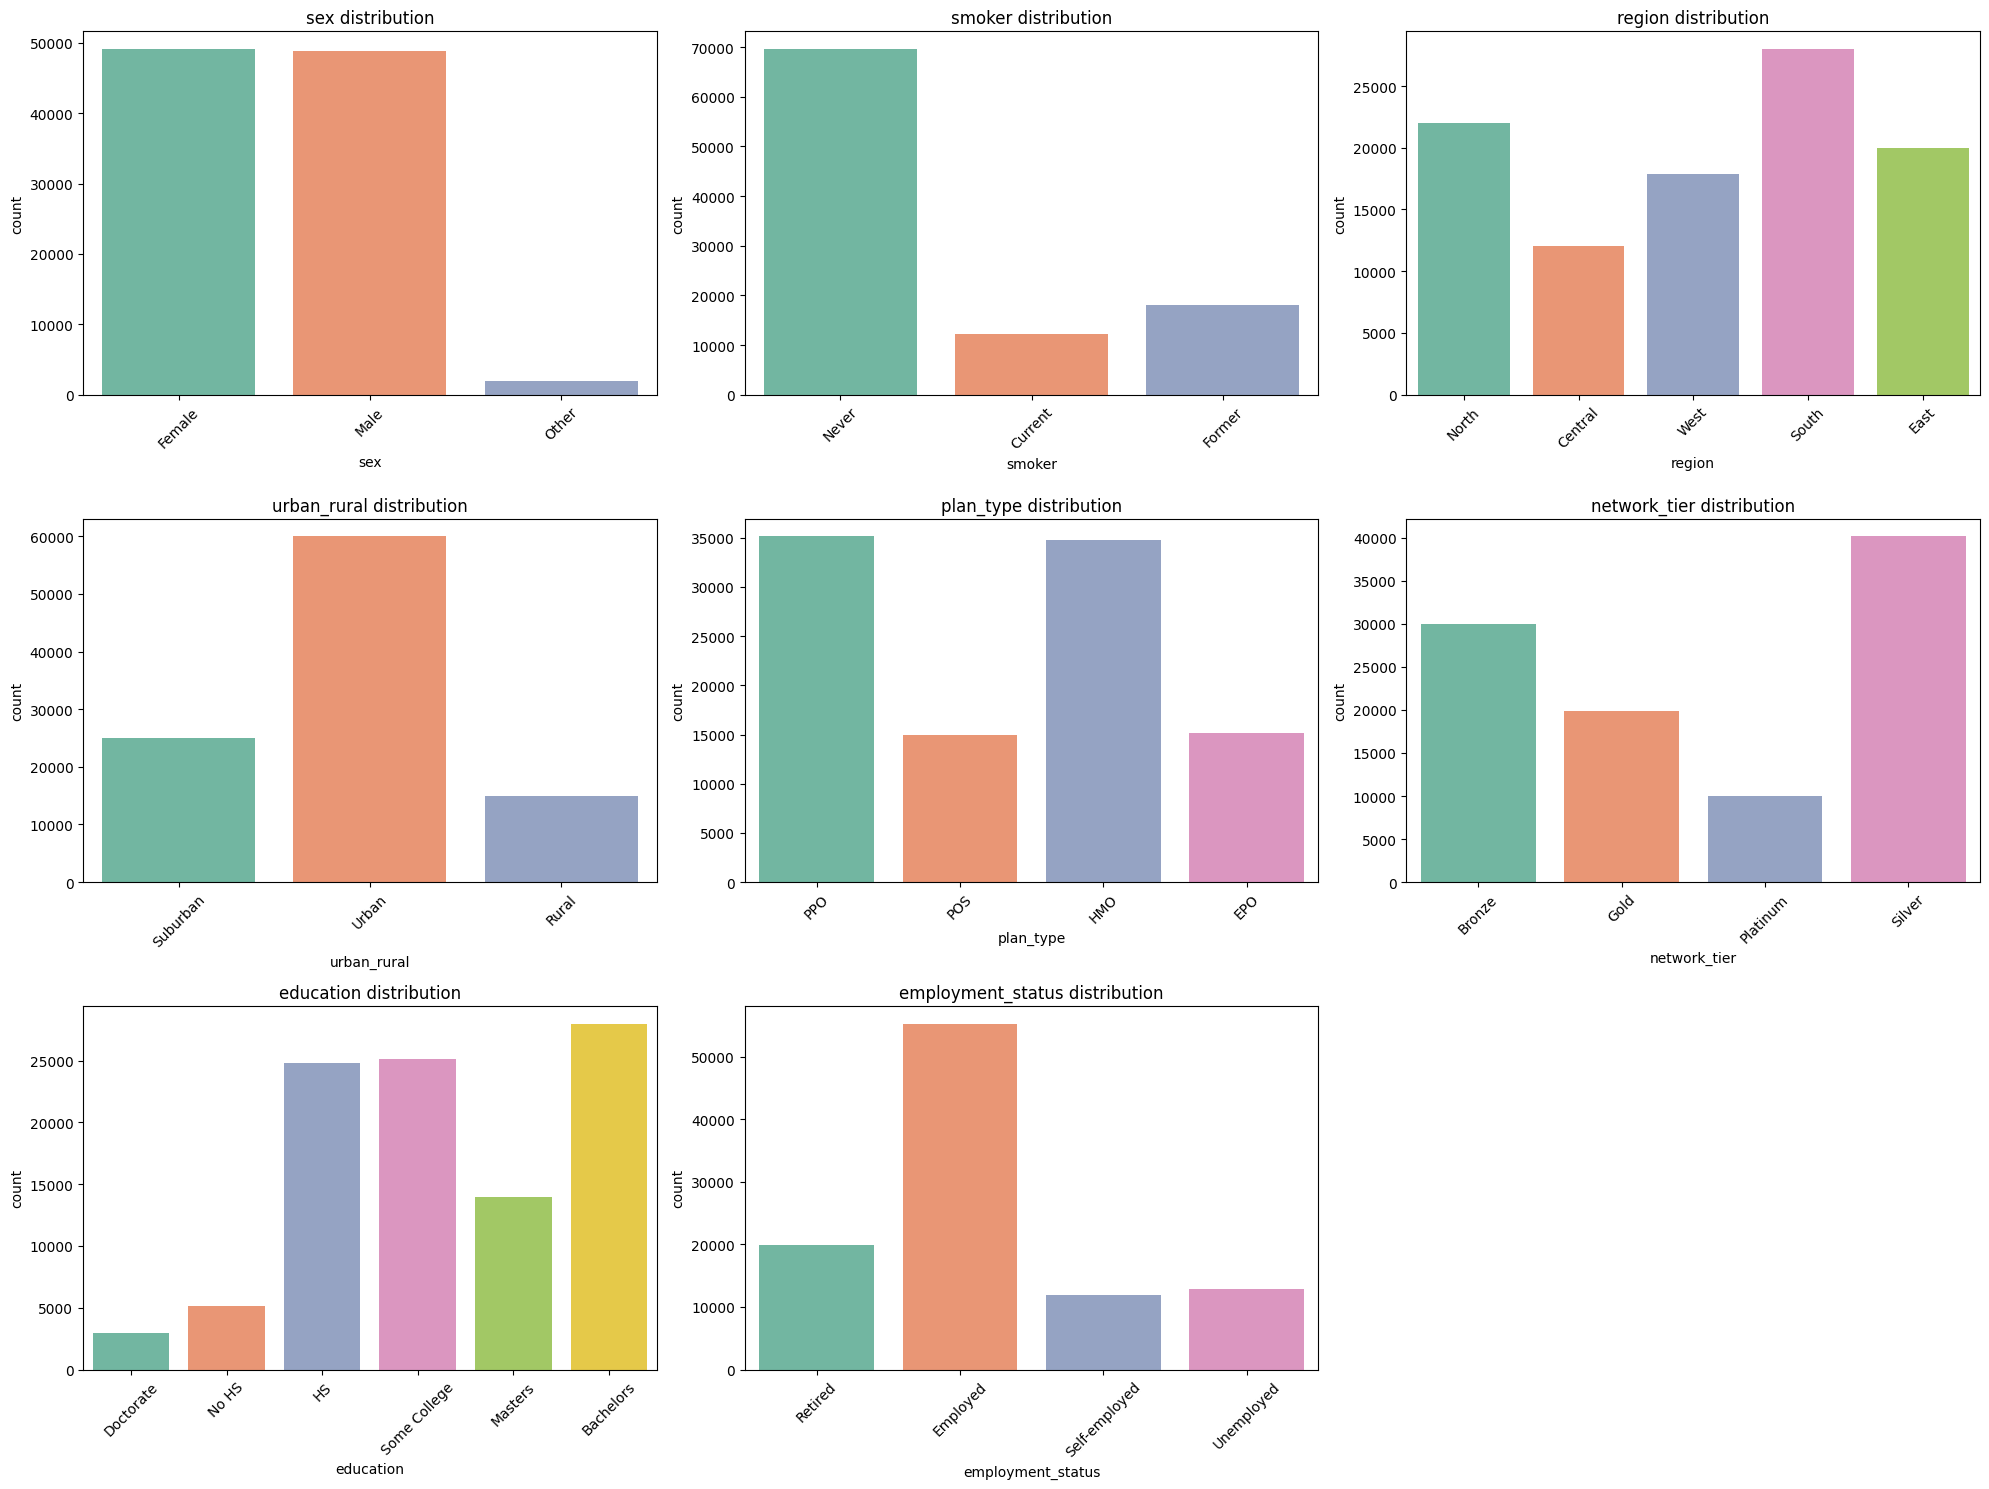

In [171]:
cat_cols = ['sex','smoker','region','urban_rural','plan_type','network_tier','education','employment_status']

plt.figure(figsize=(20,15))
for i, col in enumerate(cat_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df, x=col, hue=col, palette='Set2', legend=False)
    plt.xticks(rotation=45)
    plt.title(f'{col} distribution')
plt.tight_layout()
plt.show()

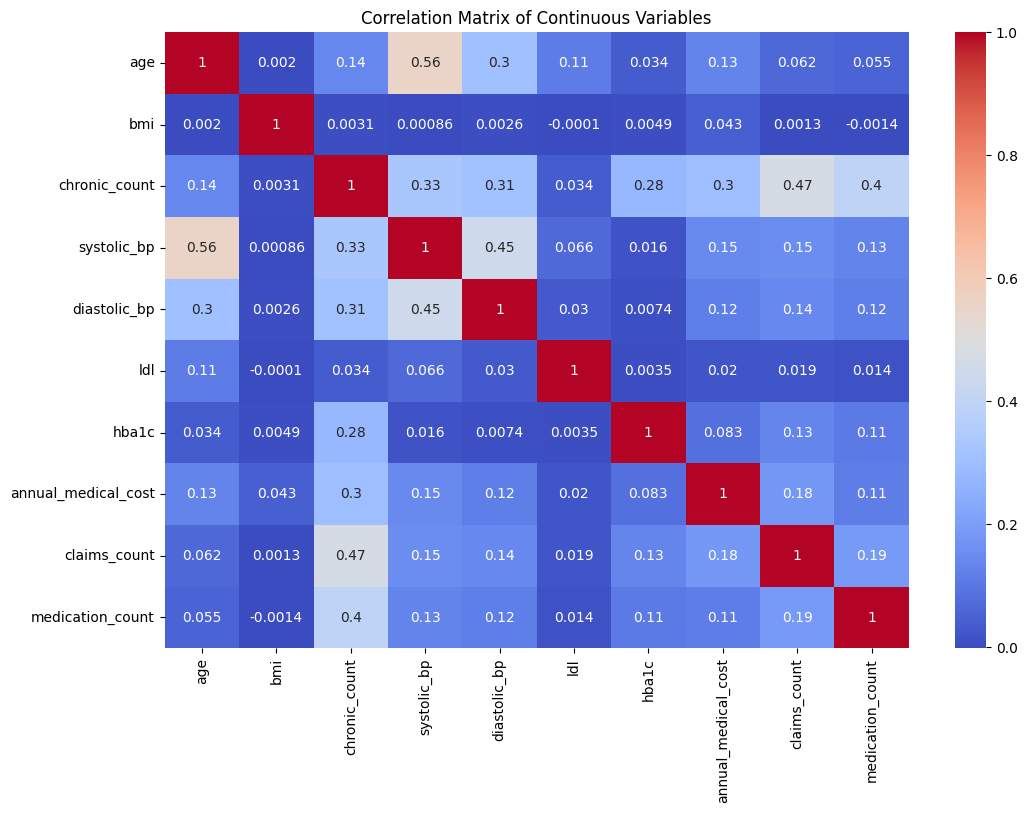

In [172]:
corr = df[num_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Continuous Variables")
plt.show()

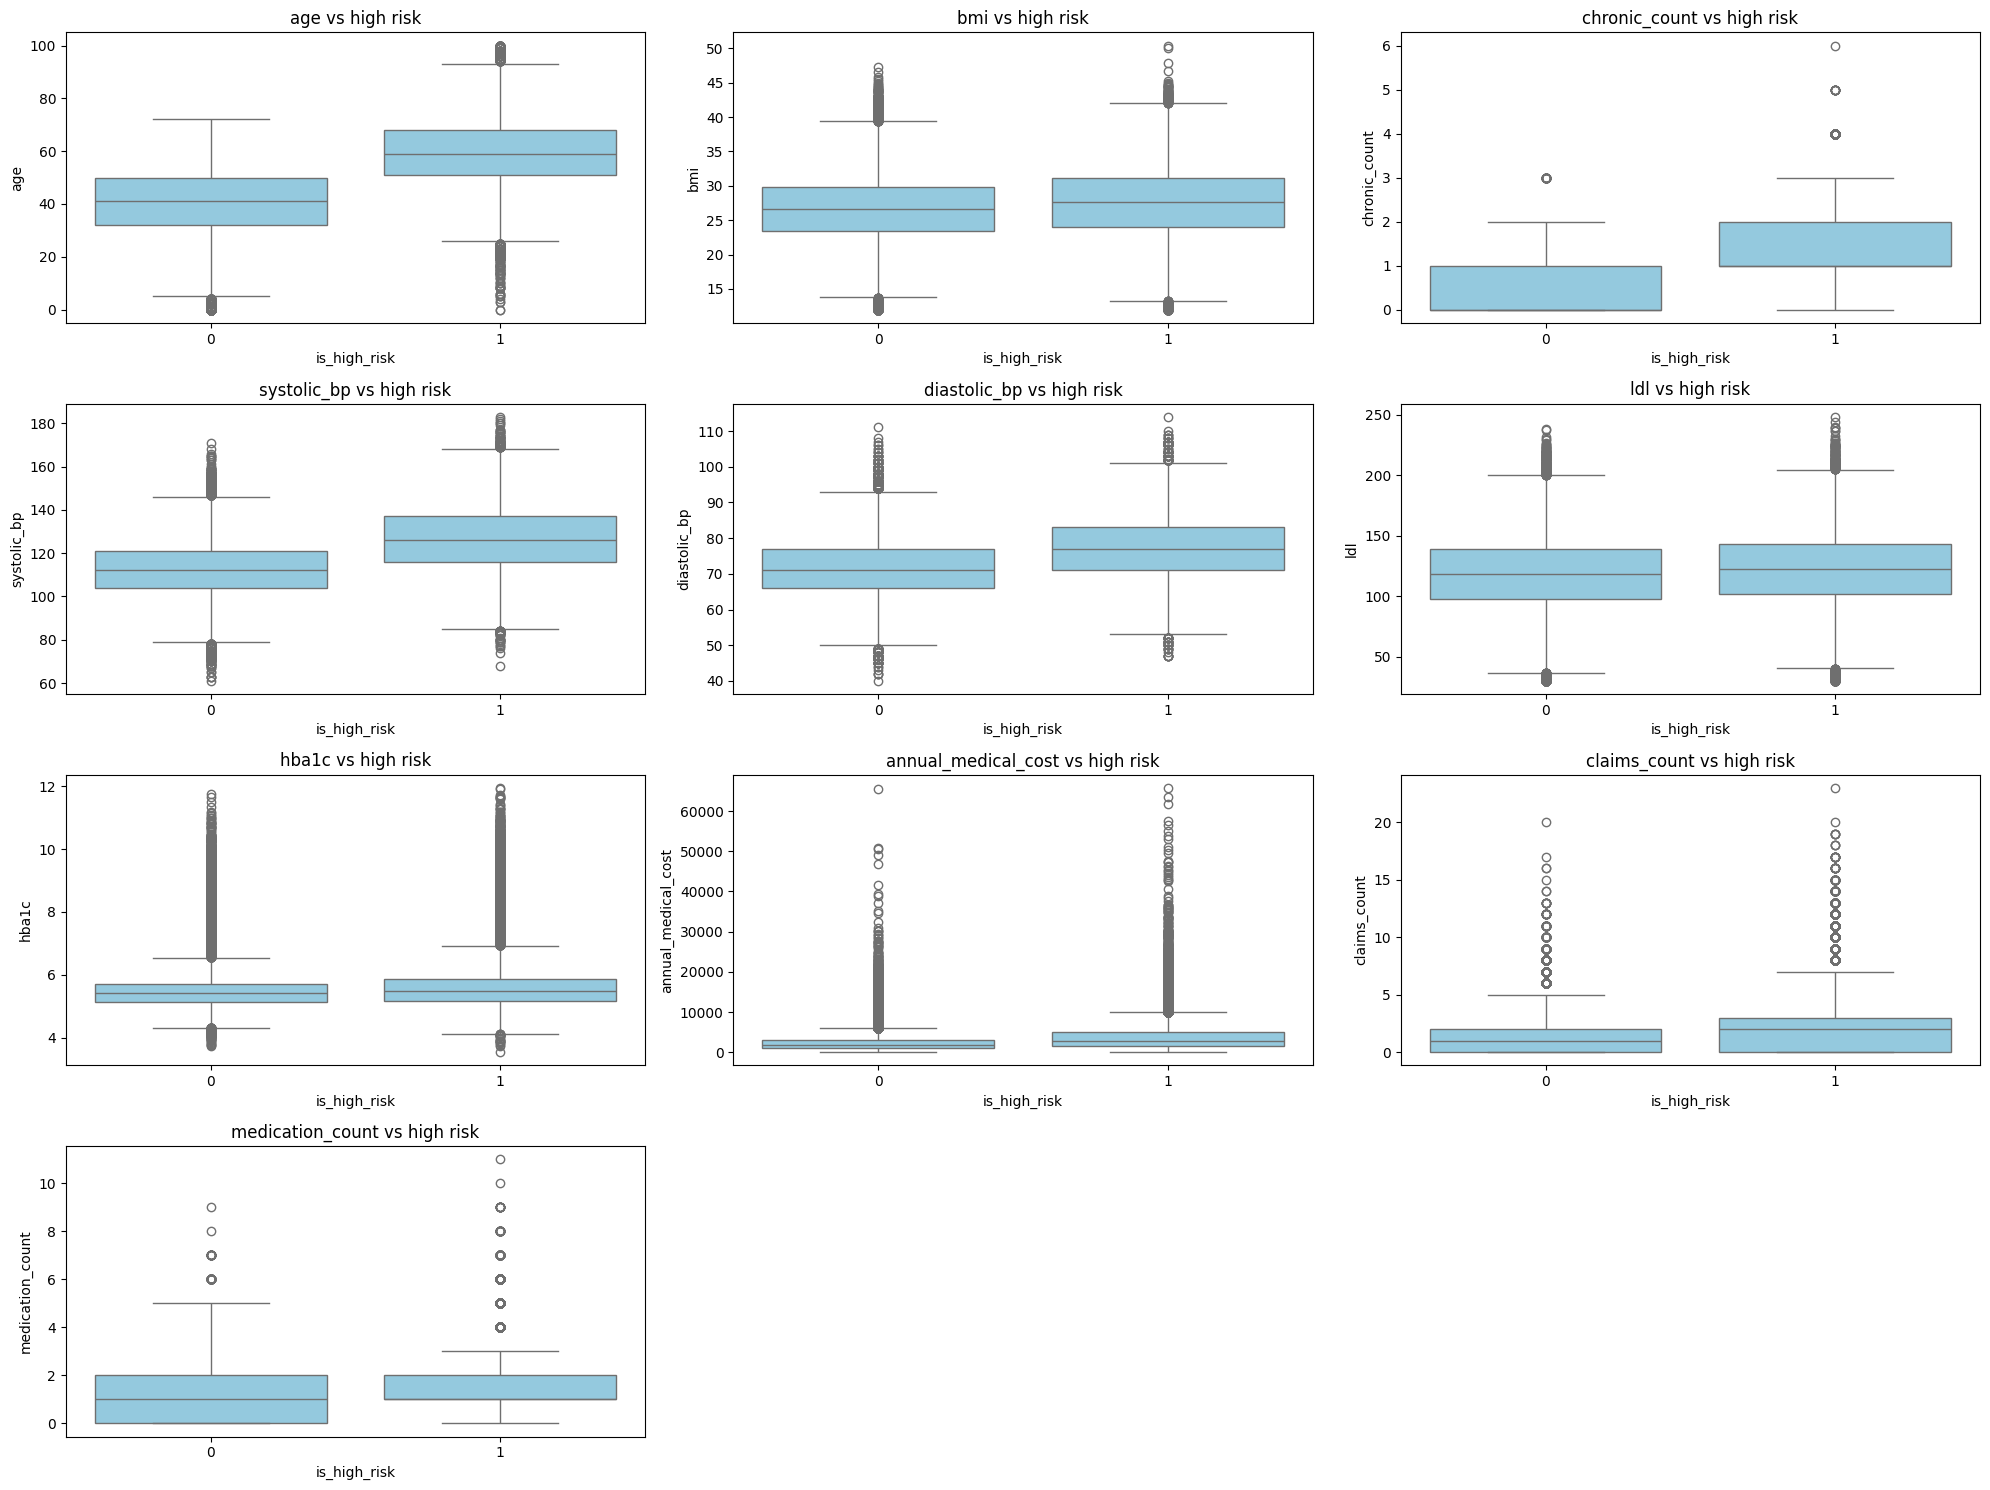

In [173]:
plt.figure(figsize=(20,15))
for i, col in enumerate(num_cols):
    plt.subplot(4,3,i+1)
    sns.boxplot(x='is_high_risk', y=col, data=df, color='skyblue')
    plt.title(f'{col} vs high risk')
plt.tight_layout()
plt.show()

In [174]:
cat_cols = [
    # Demographics & Socioeconomic
    'sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status',

    # Lifestyle & Habits
    'smoker', 'alcohol_freq',

    # Health & Clinical
    'hypertension', 'diabetes', 'copd', 'cancer_history',
    'kidney_disease', 'liver_disease', 'arthritis', 'mental_health',

    # Insurance & Policy
    'plan_type', 'network_tier', 'provider_quality'
]

In [175]:
for col in cat_cols:
    table = pd.crosstab(df[col], df['is_high_risk'])
    chi2, p, _, _ = chi2_contingency(table)
    print(f"{col}: p-value={p:.4f}")

sex: p-value=0.1316
region: p-value=0.3299
urban_rural: p-value=0.3170
education: p-value=0.0079
marital_status: p-value=0.1841
employment_status: p-value=0.5495
smoker: p-value=0.0000
alcohol_freq: p-value=0.0840
hypertension: p-value=0.0000
diabetes: p-value=0.0000
copd: p-value=0.0000
cancer_history: p-value=0.0000
kidney_disease: p-value=0.0000
liver_disease: p-value=0.0000
arthritis: p-value=0.0000
mental_health: p-value=0.0000
plan_type: p-value=0.3811
network_tier: p-value=0.2039
provider_quality: p-value=0.7356


### Categorical Feature Selection for Machine Learning Model

We performed a Chi-squared test to assess the association between categorical variables and the target variable `is_high_risk`. Variables with p-values below 0.05 were considered significantly associated with the target and will be included in the model.  

**Significant categorical variables selected for modeling:**  
- `education`  
- `smoker`  
- `hypertension`  
- `diabetes`  
- `copd`  
- `cancer_history`  
- `kidney_disease`  
- `liver_disease`  
- `arthritis`  
- `mental_health`  

Variables such as `sex`, `region`, `urban_rural`, `marital_status`, `employment_status`, `alcohol_freq`, `plan_type`, `network_tier`, and `provider_quality` showed no significant association (p > 0.05) and will not be used as categorical features in the model.


In [177]:
relevant_cat_cols = [
    'education', 'smoker', 'hypertension', 'diabetes', 'copd',
    'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health'
]

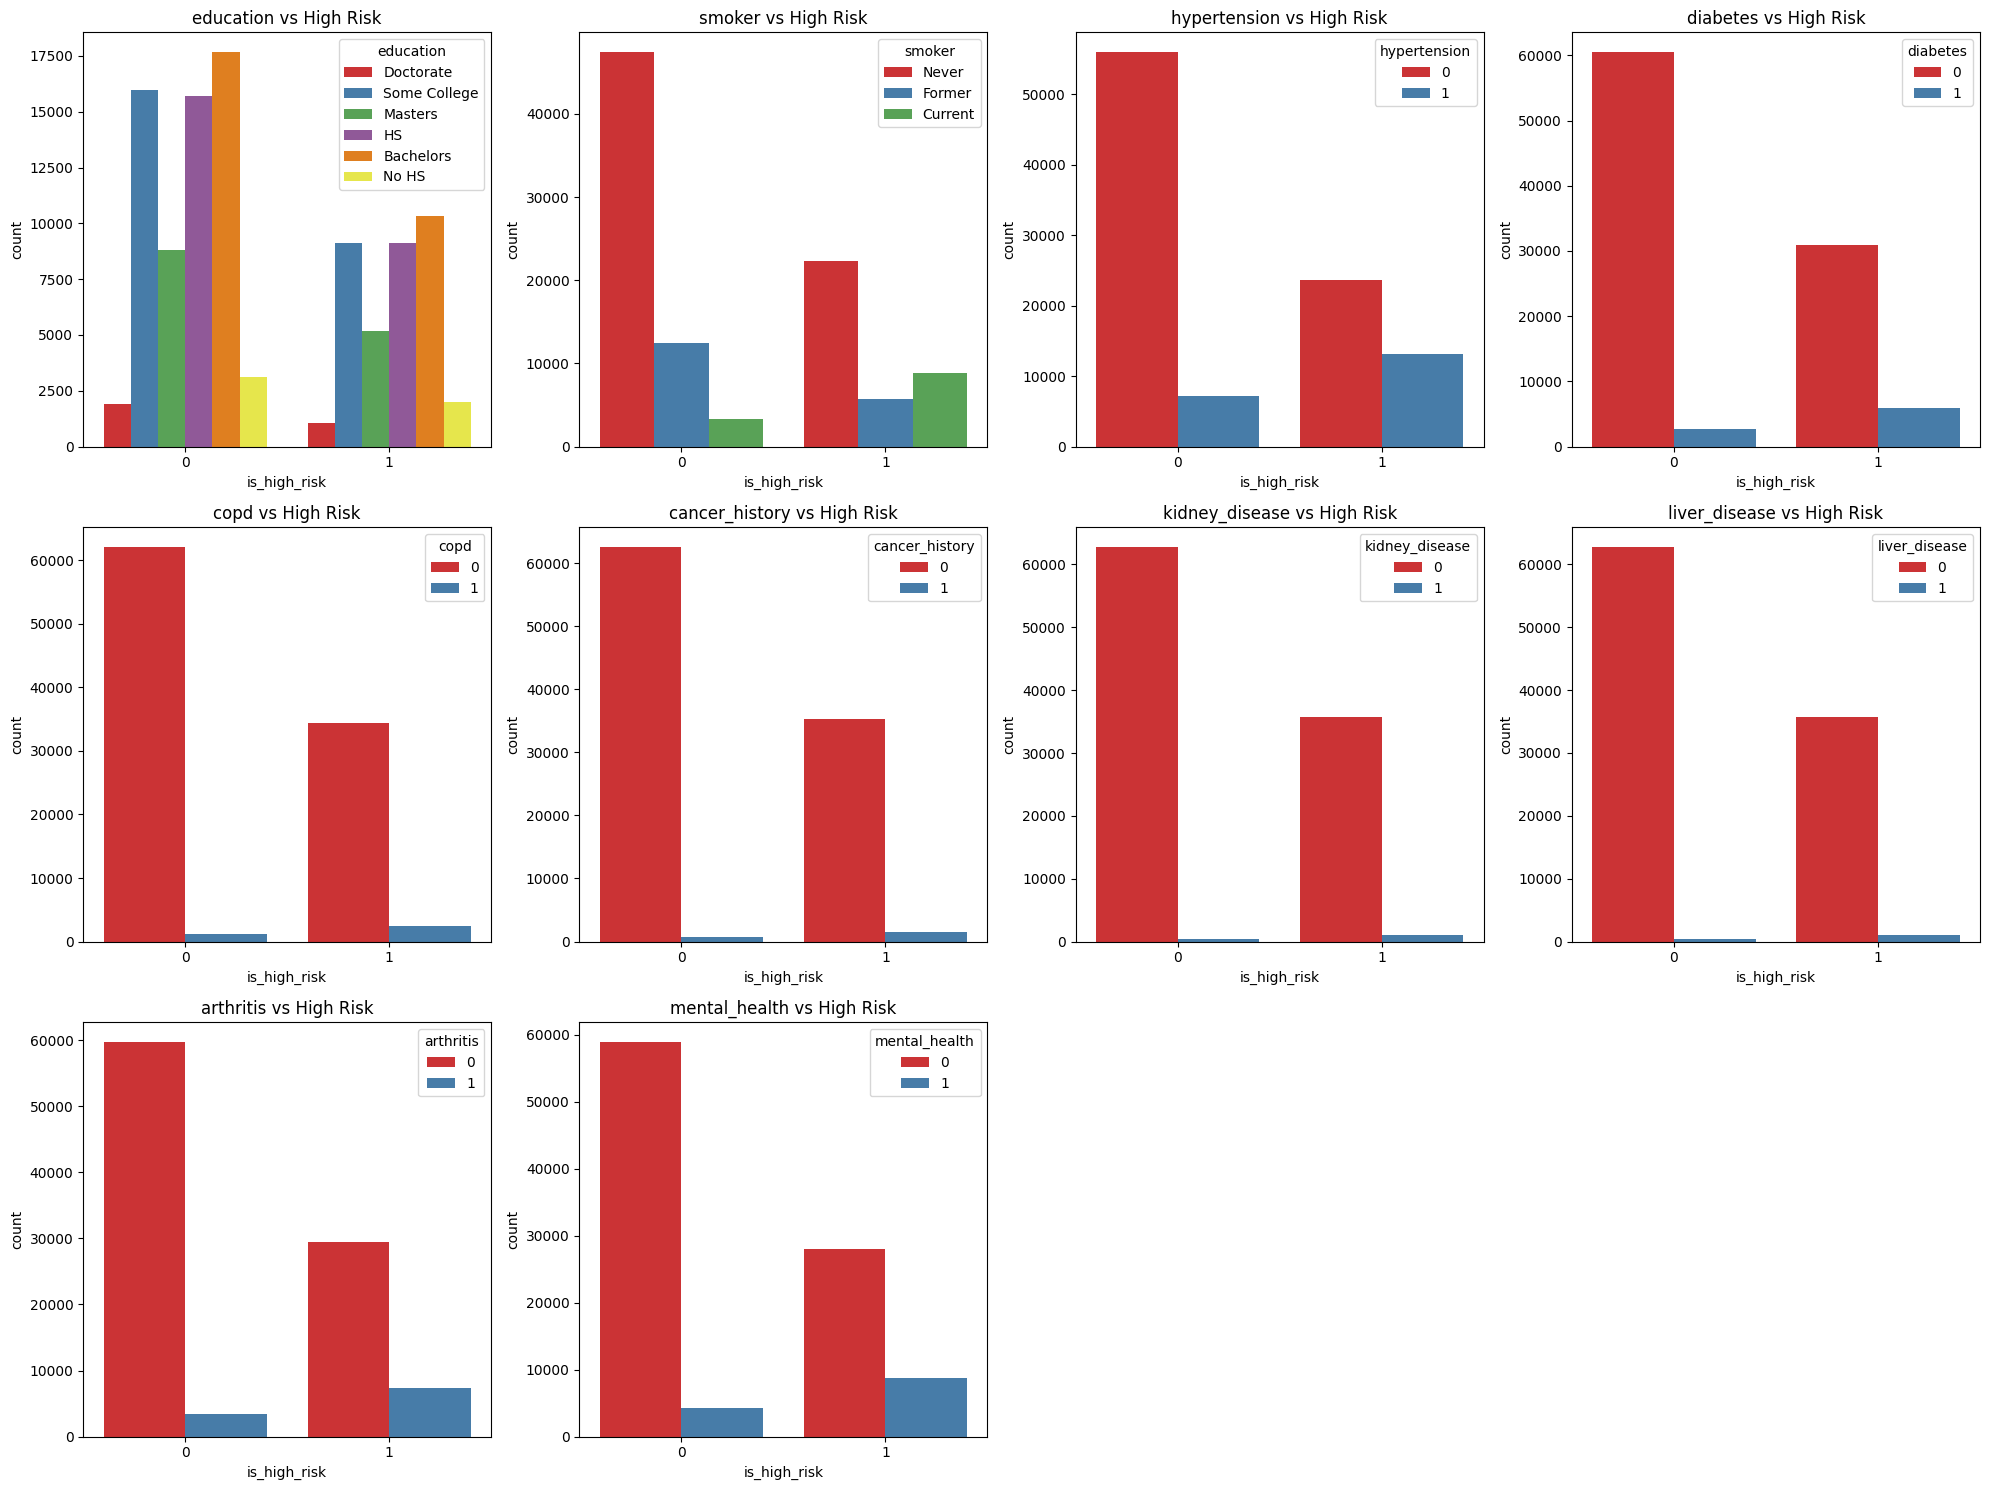

In [178]:
plt.figure(figsize=(20,15))

for i, col in enumerate(relevant_cat_cols):
    plt.subplot(3,4,i+1)
    sns.countplot(x='is_high_risk', hue=col, data=df, palette='Set1')
    plt.title(f'{col} vs High Risk')

plt.tight_layout()
plt.show()

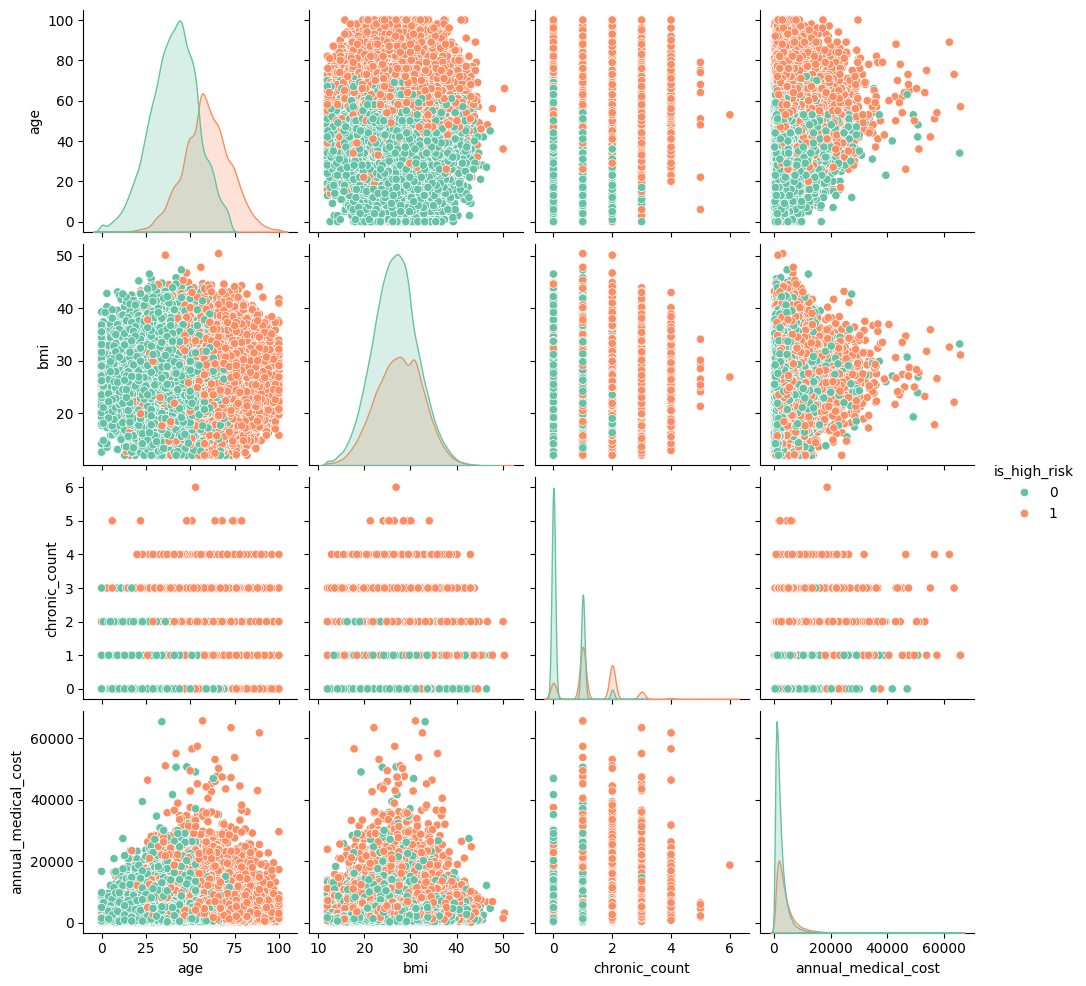

In [179]:
selected = ['age','bmi','chronic_count','annual_medical_cost','is_high_risk']
sns.pairplot(df[selected], hue='is_high_risk', palette='Set2')
plt.show()

In [180]:
for col in num_cols:
    groups = [group[col].values for name, group in df.groupby('is_high_risk')]
    stat, p = kruskal(*groups)
    print(f"{col}: p-value={p:.4f}")

age: p-value=0.0000
bmi: p-value=0.0000
chronic_count: p-value=0.0000
systolic_bp: p-value=0.0000
diastolic_bp: p-value=0.0000
ldl: p-value=0.0000
hba1c: p-value=0.0000
annual_medical_cost: p-value=0.0000
claims_count: p-value=0.0000
medication_count: p-value=0.0000


### Numerical Feature Selection for Machine Learning Model

We used the Kruskal-Wallis test to evaluate the association between numerical variables and the target `is_high_risk`. All tested variables showed significant differences between high-risk and low-risk groups (p < 0.05) and will be included as features in the model.

**Selected numerical variables:**  
- `age`  
- `bmi`  
- `chronic_count`  
- `systolic_bp`  
- `diastolic_bp`  
- `ldl`  
- `hba1c`  
- `annual_medical_cost`  
- `claims_count`  
- `medication_count`

/tmp/ipython-input-1404463851.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


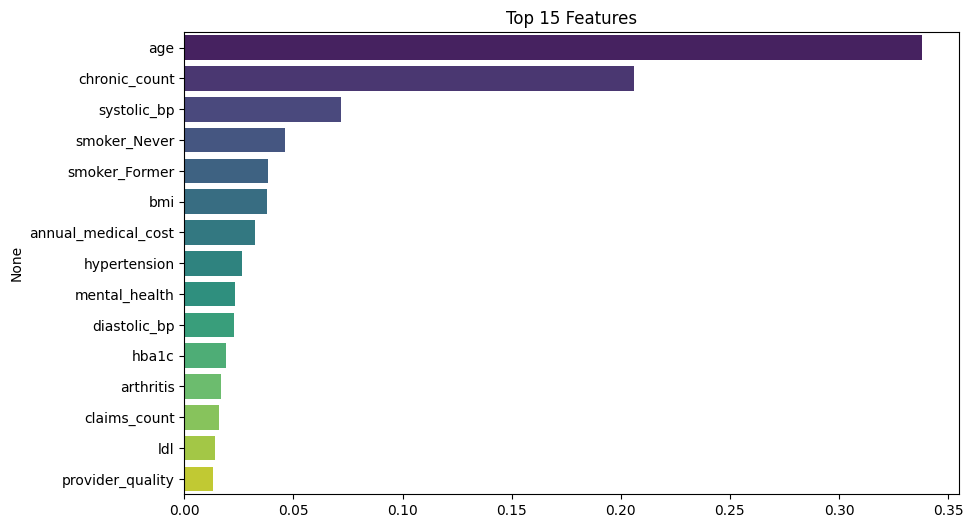

In [181]:
X = df[num_cols + cat_cols].copy()

X = pd.get_dummies(X, drop_first=True)
y = LabelEncoder().fit_transform(df['is_high_risk'])

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Top 15 Features")
plt.show()

# Models

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix


features = [ 'age','sex', 'region', 'urban_rural', 'income', 'education',
    'marital_status', 'employment_status', 'household_size', 'dependents',
    'bmi', 'smoker', 'visits_last_year', 'hospitalizations_last_3yrs',
    'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp',
    'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible',
    'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality',
    'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count',
    'proc_consult_count', 'proc_lab_count', 'had_major_procedure'
]


In [126]:
#ML preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X=df[features]
y= df['risk_score']
# y = (y > 0.5).astype(int) #for two classes
y = pd.qcut(y, q=3, labels=['low', 'medium', 'high']) #for tree classes

print(y.value_counts())

# var cat
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)
# normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
len(X_train_scaled)

risk_score
low       35039
high      32619
medium    32342
Name: count, dtype: int64


80000

In [ ]:
y_train #view data training

,risk_score
25862,1
93756,1
19365,0
70280,0
20468,1
...,...
85928,1
73796,0
66938,0
70177,1


In [ ]:
y.isna().sum()  #checking if there is NaN

np.int64(0)

## GridSearchCV et RandomizedSearchCV ##

In [135]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

def grid(x_train,y_train, clf,param_grid):

    grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(x_train, y_train)
    best_params = grid_search.best_params_
    print("Melhores parâmetros encontrados:", best_params)
    best_model = grid_search.best_estimator_

    return best_model

def randomized(x_train, y_train, clf, param_dist, n_iter=10):

    random_search = RandomizedSearchCV(clf, param_distributions=param_dist, n_iter=n_iter, cv=5,
        scoring='accuracy', n_jobs=-1, verbose=1, random_state=42)

    random_search.fit(x_train, y_train)

    best_params = random_search.best_params_
    print("Melhores parâmetros encontrados:", best_params)

    best_model = random_search.best_estimator_

    return best_model


### Random Forest ###

In [131]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

clf = RandomForestClassifier(random_state=42)

params_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [133]:
def rf (best_param):
  best_param.fit(X_train, y_train)
  y_pred = best_param.predict(X_test)

  print(classification_report(y_test, y_pred))

  cm=confusion_matrix(y_test, y_pred)

  plt.figure(figsize=(6,5))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()


#### With 3 classes (low, medium, high)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Melhores parâmetros encontrados: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}
              precision    recall  f1-score   support

        high       0.86      0.81      0.83      6524
         low       0.82      0.92      0.87      7008
      medium       0.73      0.68      0.70      6468

    accuracy                           0.81     20000
   macro avg       0.81      0.80      0.80     20000
weighted avg       0.81      0.81      0.81     20000



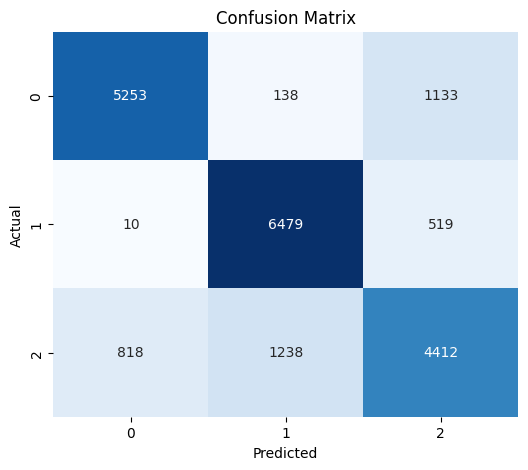

In [136]:
#RandomizedSearchCV
best_rf_random = randomized(X_train,y_train, clf,params_rf)
rf(best_rf_random)

In [ ]:
#Grid SearchCV (3)
best_rf_grid = grid(X_train,y_train, clf,params_rf)
rf(best_rf_grid)

####With 2 classes (low, high)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhores parâmetros encontrados: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      9885
           1       0.91      0.87      0.89     10115

    accuracy                           0.89     20000
   macro avg       0.89      0.89      0.89     20000
weighted avg       0.89      0.89      0.89     20000



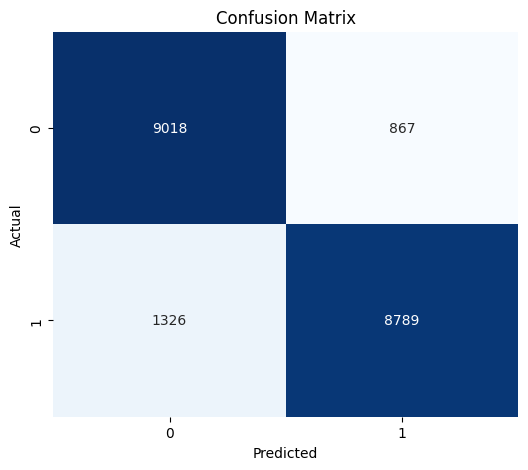

In [ ]:
#RandomizedSearchCV
best_rf_random = randomized(X_train,y_train, clf,params_rf)
rf(best_rf_random)

In [ ]:
#Grid SearchCV (2)
best_rf_grid = grid(X_train,y_train, clf,params_rf)
rf(best_rf_grid)

### XGBoost ###

In [128]:
from xgboost import XGBClassifier
from scipy.stats import randint, uniform
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# xgb = XGBClassifier(objective='binary:logistic', random_state=42) #for 2 classes

xgb = XGBClassifier(objective='multi:softmax', num_class=3, random_state=42) #for 3 classes

param_dist_xgb = {
    'n_estimators': randint(200, 800),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
}

param_grid_xgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}


In [ ]:
def xg_result(best_model, X_train, y_train, X_test, y_test):
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

####With 3 classes (low, medium, high)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Melhores parâmetros encontrados: {'colsample_bytree': np.float64(0.842571623863836), 'learning_rate': np.float64(0.01183941032332593), 'max_depth': 8, 'n_estimators': 672, 'subsample': np.float64(0.8654007076432223)}
              precision    recall  f1-score   support

           0       0.89      0.80      0.85      6524
           1       0.84      0.92      0.88      7008
           2       0.73      0.73      0.73      6468

    accuracy                           0.82     20000
   macro avg       0.82      0.82      0.82     20000
weighted avg       0.82      0.82      0.82     20000



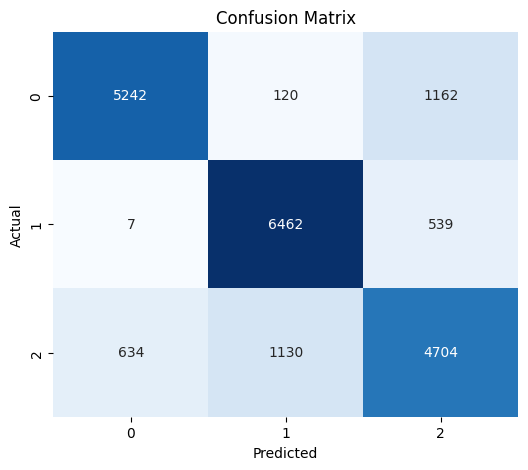

In [129]:
# Randomized Search
best_xgb_random = randomized(X_train, y_train_enc, xgb, param_dist_xgb, n_iter=50)
xg_result(best_xgb_random, X_train, y_train_enc, X_test, y_test_enc)


In [ ]:
# GridSearchCV
best_xgb_grid = grid(X_train, y_train_enc, xgb, param_grid_xgb)
xg_result(best_xgb_grid, X_train, y_train_enc, X_test, y_test_enc)

####With 2 classes (low, high)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Melhores parâmetros encontrados: {'colsample_bytree': np.float64(0.842571623863836), 'learning_rate': np.float64(0.01183941032332593), 'max_depth': 8, 'n_estimators': 672, 'subsample': np.float64(0.8654007076432223)}
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      9885
           1       0.93      0.87      0.90     10115

    accuracy                           0.90     20000
   macro avg       0.90      0.90      0.90     20000
weighted avg       0.90      0.90      0.90     20000



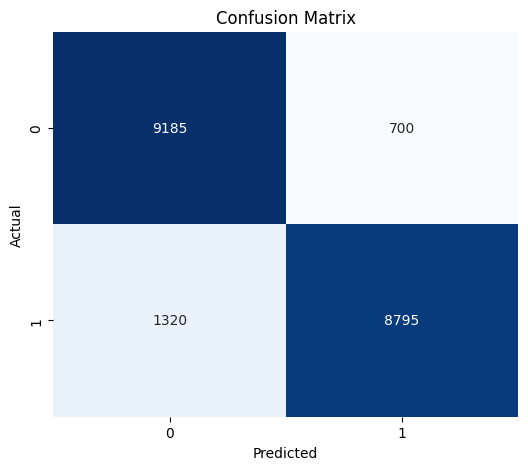

In [ ]:
# Randomized Search
best_xgb_random = randomized(X_train, y_train_enc, xgb, param_dist_xgb, n_iter=50)
xg_result(best_xgb_random, X_train, y_train_enc, X_test, y_test_enc)


In [ ]:
# GridSearchCV
best_xgb_grid = grid(X_train, y_train_enc, xgb, param_grid_xgb)
xg_result(best_xgb_grid, X_train, y_train_enc, X_test, y_test_enc)

### Logistic Regression ###

In [ ]:
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform

#with RandomizedSearchCV
#Logistic Regression

lr = LogisticRegression(max_iter=1000)
param_random = {
    'C': uniform(0.01, 10),
    'solver': ['liblinear', 'lbfgs']
}

param_grid = {
    "C": [0.01, 0.1, 1, 10],     # lista OK
    "solver": ["lbfgs", "liblinear"],
    "penalty": ["l2"]
}

In [ ]:
#Logistic Regression
def LR(best_param):
  best_param.fit(X_train, y_train)

  previsoes_lr = best_param.predict(X_test)

  report = classification_report(y_test, previsoes_lr)
  cm = confusion_matrix(y_test, previsoes_lr)
  print(report)
  plt.figure(figsize=(6,5))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()

####With 3 classes (low, medium, high)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhores parâmetros encontrados: {'C': np.float64(4.677628932479799), 'solver': 'liblinear'}
              precision    recall  f1-score   support

        high       0.59      0.78      0.67      6524
         low       0.70      0.84      0.76      7008
      medium       0.47      0.21      0.28      6468

    accuracy                           0.62     20000
   macro avg       0.58      0.61      0.57     20000
weighted avg       0.59      0.62      0.58     20000



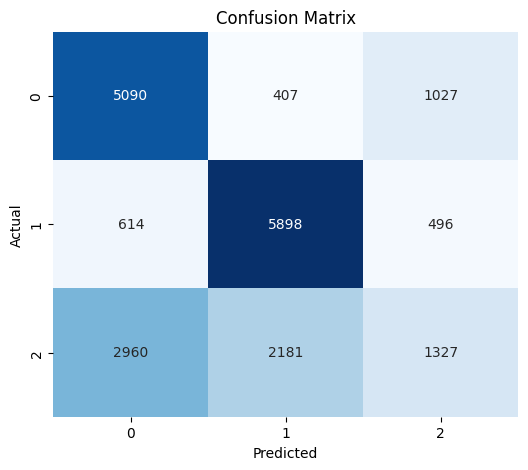

In [127]:
#RandomizedSearchCV
best_lr_random = randomized(X_train, y_train, lr,param_random)
LR(best_lr_random)

In [ ]:
# GridSearchCV
best_lr_grid = grid(X_train, y_train, lr,param_grid)
LR(best_lr_grid)

####With 2 classes (low, high)



Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhores parâmetros encontrados: {'C': np.float64(5.996584841970366), 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      9885
           1       0.87      0.86      0.86     10115

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



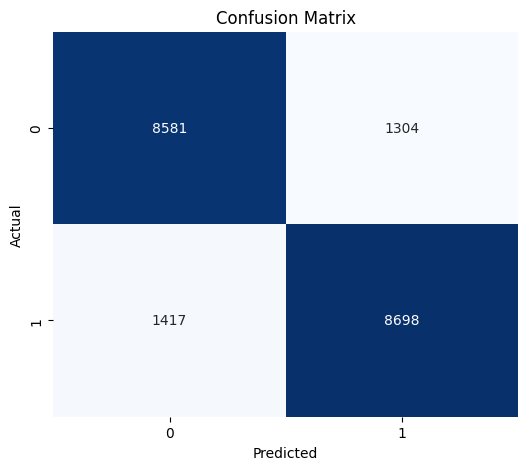

In [ ]:
#RandomizedSearchCV
best_lr_random = randomized(X_train, y_train, lr,param_random)
LR(best_lr_random)

In [ ]:
# GridSearchCV
best_lr_grid = grid(X_train, y_train, lr,param_grid)
LR(best_lr_grid)

### Decision Tree ###

In [90]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=42)

dt_param = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Decision Tree test
def DT(best_dt_random):
  best_dt_random.fit(X_train, y_train)

  y_pred = best_dt_random.predict(X_test)

  print(classification_report(y_test, y_pred))

  cm=confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(6,5))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()

####With 3 classes (low, medium, high)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhores parâmetros encontrados: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10, 'criterion': 'gini'}
              precision    recall  f1-score   support

        high       0.86      0.75      0.80      6524
         low       0.82      0.88      0.85      7008
      medium       0.67      0.69      0.68      6468

    accuracy                           0.78     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.78      0.78      0.78     20000



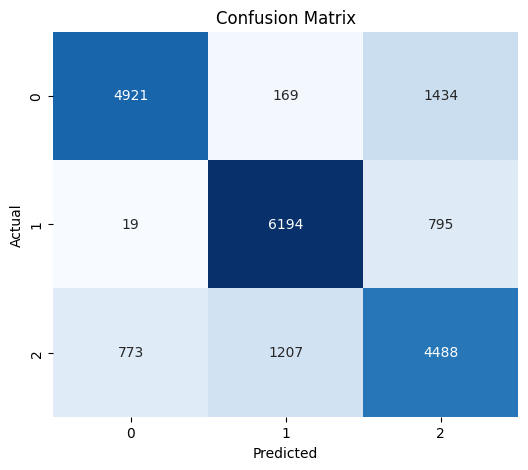

In [123]:
# RandomizedSearchCV
best_dt_random = randomized(X_train, y_train, dt_clf, dt_param)
DT(best_dt_random)

In [ ]:
# GridSearchCV
best_dt_grid = grid(X_train, y_train, dt_clf, dt_param)
DT(best_dt_grid)

####With 2 classes (low, high)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhores parâmetros encontrados: {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 10, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      9885
           1       0.92      0.83      0.87     10115

    accuracy                           0.88     20000
   macro avg       0.88      0.88      0.88     20000
weighted avg       0.88      0.88      0.88     20000



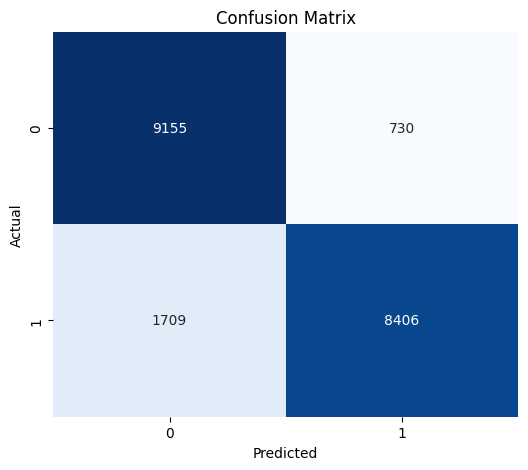

In [125]:
# RandomizedSearchCV
best_dt_random = randomized(X_train, y_train, dt_clf, dt_param)
DT(best_dt_random)

In [ ]:
# GridSearchCV
best_dt_grid = grid(X_train, y_train, dt_clf, dt_param)
DT(best_dt_grid)

### PyTorch MLP for 3 classes

In [93]:
!pip install optuna

In [94]:
y= df['risk_score']
# y = (y > 0.5).astype(int) #for two classes
y = pd.qcut(y, q=3, labels=['low', 'medium', 'high']) #for tree classes


In [95]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
X = pd.get_dummies(X, drop_first=True)

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
y_encoded

array([2, 0, 0, ..., 2, 2, 1])

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [ ]:
full_train_dataset = TabularDataset(X_train_scaled, y_train)
test_dataset = TabularDataset(X_test_scaled, y_test)

In [ ]:
val_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [ ]:
import torch.nn as nn
import numpy as np

input_dim = X_train_scaled.shape[1]
num_classes = len(np.unique(y_train))

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
model = MLP(input_dim, num_classes)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)


In [ ]:
epochs = 30

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

In [ ]:
train_losses = []
train_accuracies = []

for epoch in range(30):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # accuracy del batch
        _, preds = outputs.max(1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_losses.append(epoch_loss / len(train_loader))
    train_accuracies.append(correct / total)

    print(f"Epoch {epoch+1}: Loss={train_losses[-1]:.4f}, Acc={train_accuracies[-1]:.4f}")

Epoch 1: Loss=0.4841, Acc=0.7865
Epoch 2: Loss=0.4839, Acc=0.7869
Epoch 3: Loss=0.4840, Acc=0.7872
Epoch 4: Loss=0.4836, Acc=0.7890
Epoch 5: Loss=0.4807, Acc=0.7874
Epoch 6: Loss=0.4791, Acc=0.7915
Epoch 7: Loss=0.4793, Acc=0.7906
Epoch 8: Loss=0.4790, Acc=0.7902
Epoch 9: Loss=0.4771, Acc=0.7897
Epoch 10: Loss=0.4815, Acc=0.7891
Epoch 11: Loss=0.4753, Acc=0.7926
Epoch 12: Loss=0.4763, Acc=0.7910
Epoch 13: Loss=0.4778, Acc=0.7916
Epoch 14: Loss=0.4743, Acc=0.7924
Epoch 15: Loss=0.4753, Acc=0.7933
Epoch 16: Loss=0.4761, Acc=0.7911
Epoch 17: Loss=0.4772, Acc=0.7928
Epoch 18: Loss=0.4738, Acc=0.7918
Epoch 19: Loss=0.4753, Acc=0.7922
Epoch 20: Loss=0.4744, Acc=0.7919
Epoch 21: Loss=0.4754, Acc=0.7929
Epoch 22: Loss=0.4742, Acc=0.7939
Epoch 23: Loss=0.4765, Acc=0.7925
Epoch 24: Loss=0.4757, Acc=0.7904
Epoch 25: Loss=0.4710, Acc=0.7951
Epoch 26: Loss=0.4765, Acc=0.7919
Epoch 27: Loss=0.4746, Acc=0.7934
Epoch 28: Loss=0.4751, Acc=0.7944
Epoch 29: Loss=0.4738, Acc=0.7956
Epoch 30: Loss=0.4733, 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.numpy())

print(classification_report(y_true, y_pred))

cm=confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import optuna
import torch.nn as nn

def create_model(input_dim, num_classes, n_layers, n_neurons):
    layers = []
    in_features = input_dim

    for _ in range(n_layers):
        layers.append(nn.Linear(in_features, n_neurons))
        layers.append(nn.ReLU())
        in_features = n_neurons

    layers.append(nn.Linear(in_features, num_classes))
    return nn.Sequential(*layers)


def objective(trial):

    # hiperparámetros a tunear
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    n_layers = trial.suggest_int("n_layers", 1, 4)
    n_neurons = trial.suggest_int("n_neurons", 16, 256)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    train_loader_hp = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model_hp = create_model(input_dim, num_classes, n_layers, n_neurons)
    optimizer = torch.optim.Adam(model_hp.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model_hp.train()
    for epoch in range(5):  # entrenamos poco para no tardar horas
        for X_batch, y_batch in train_loader_hp:
            optimizer.zero_grad()
            outputs = model_hp(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    # evaluación rápida
    model_hp.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            outputs = model_hp(Xb)
            _, preds = outputs.max(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    accuracy = correct / total
    return accuracy


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)


In [ ]:
print("Best accuracy:", study.best_value)
print("Best params:", study.best_params)

In [ ]:
best = study.best_params

final_model = create_model(
    input_dim,
    num_classes,
    best["n_layers"],
    best["n_neurons"]
)

optimizer = torch.optim.Adam(final_model.parameters(), lr=best["lr"])

In [ ]:
optimizer = torch.optim.Adam(final_model.parameters(), lr=best["lr"])
criterion = nn.CrossEntropyLoss()

In [ ]:
final_train_loader = DataLoader(train_dataset, batch_size=best["batch_size"], shuffle=True)

In [ ]:
num_epochs = 30
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    final_model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in final_train_loader:
        optimizer.zero_grad()
        outputs = final_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        _, preds = outputs.max(1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_losses.append(epoch_loss / len(final_train_loader))
    train_accuracies.append(correct / total)

    print(f"Epoch {epoch+1}: Loss={train_losses[-1]:.4f}, Acc={train_accuracies[-1]:.4f}")


In [ ]:
final_model.eval()
all_preds = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = final_model(X_batch)
        _, preds = outputs.max(1)
        all_preds.append(preds)

all_preds = torch.cat(all_preds)

In [ ]:
print(classification_report(y_test, all_preds))

              precision    recall  f1-score   support

           0       0.83      0.76      0.79      6524
           1       0.81      0.83      0.82      7008
           2       0.63      0.67      0.65      6468

    accuracy                           0.75     20000
   macro avg       0.76      0.75      0.75     20000
weighted avg       0.76      0.75      0.76     20000



### PyTorch MLP for 2 classes

In [98]:
!pip install optuna

In [99]:
y= df['risk_score']
y = (y > 0.5).astype(int) #for two classes
# y = pd.qcut(y, q=3, labels=['low', 'medium', 'high']) #for tree classes


In [100]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
X = pd.get_dummies(X, drop_first=True)

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [102]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [103]:
y_encoded

array([1, 1, 1, ..., 0, 1, 0])

In [104]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [105]:
full_train_dataset = TabularDataset(X_train_scaled, y_train)
test_dataset = TabularDataset(X_test_scaled, y_test)

In [106]:
val_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [107]:
import torch.nn as nn
import numpy as np

input_dim = X_train_scaled.shape[1]
num_classes = len(np.unique(y_train))

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [108]:
model = MLP(input_dim, num_classes)

In [109]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)


In [110]:
epochs = 30

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

Epoch 1/30 | Train Loss: 0.3215 | Val Loss: 0.3204
Epoch 2/30 | Train Loss: 0.3003 | Val Loss: 0.2979
Epoch 3/30 | Train Loss: 0.2927 | Val Loss: 0.2909
Epoch 4/30 | Train Loss: 0.2896 | Val Loss: 0.2903
Epoch 5/30 | Train Loss: 0.2857 | Val Loss: 0.3154
Epoch 6/30 | Train Loss: 0.2821 | Val Loss: 0.2932
Epoch 7/30 | Train Loss: 0.2804 | Val Loss: 0.2968
Epoch 8/30 | Train Loss: 0.2764 | Val Loss: 0.2904
Epoch 9/30 | Train Loss: 0.2765 | Val Loss: 0.2963
Epoch 10/30 | Train Loss: 0.2735 | Val Loss: 0.3007
Epoch 11/30 | Train Loss: 0.2725 | Val Loss: 0.2944
Epoch 12/30 | Train Loss: 0.2695 | Val Loss: 0.2992
Epoch 13/30 | Train Loss: 0.2667 | Val Loss: 0.3222
Epoch 14/30 | Train Loss: 0.2656 | Val Loss: 0.3054
Epoch 15/30 | Train Loss: 0.2646 | Val Loss: 0.3029
Epoch 16/30 | Train Loss: 0.2626 | Val Loss: 0.2935
Epoch 17/30 | Train Loss: 0.2599 | Val Loss: 0.3137
Epoch 18/30 | Train Loss: 0.2597 | Val Loss: 0.3171
Epoch 19/30 | Train Loss: 0.2587 | Val Loss: 0.3113
Epoch 20/30 | Train L

In [111]:
train_losses = []
train_accuracies = []

for epoch in range(30):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # accuracy del batch
        _, preds = outputs.max(1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_losses.append(epoch_loss / len(train_loader))
    train_accuracies.append(correct / total)

    print(f"Epoch {epoch+1}: Loss={train_losses[-1]:.4f}, Acc={train_accuracies[-1]:.4f}")

Epoch 1: Loss=0.2454, Acc=0.8883
Epoch 2: Loss=0.2447, Acc=0.8893
Epoch 3: Loss=0.2445, Acc=0.8899
Epoch 4: Loss=0.2423, Acc=0.8902
Epoch 5: Loss=0.2412, Acc=0.8904
Epoch 6: Loss=0.2401, Acc=0.8918
Epoch 7: Loss=0.2404, Acc=0.8912
Epoch 8: Loss=0.2416, Acc=0.8894
Epoch 9: Loss=0.2374, Acc=0.8927
Epoch 10: Loss=0.2383, Acc=0.8915
Epoch 11: Loss=0.2377, Acc=0.8920
Epoch 12: Loss=0.2370, Acc=0.8921
Epoch 13: Loss=0.2353, Acc=0.8940
Epoch 14: Loss=0.2348, Acc=0.8928
Epoch 15: Loss=0.2342, Acc=0.8927
Epoch 16: Loss=0.2325, Acc=0.8939
Epoch 17: Loss=0.2313, Acc=0.8941
Epoch 18: Loss=0.2323, Acc=0.8938
Epoch 19: Loss=0.2314, Acc=0.8936
Epoch 20: Loss=0.2315, Acc=0.8943
Epoch 21: Loss=0.2297, Acc=0.8945
Epoch 22: Loss=0.2291, Acc=0.8942
Epoch 23: Loss=0.2291, Acc=0.8958
Epoch 24: Loss=0.2280, Acc=0.8953
Epoch 25: Loss=0.2279, Acc=0.8963
Epoch 26: Loss=0.2275, Acc=0.8973
Epoch 27: Loss=0.2272, Acc=0.8960
Epoch 28: Loss=0.2289, Acc=0.8965
Epoch 29: Loss=0.2272, Acc=0.8956
Epoch 30: Loss=0.2282, 

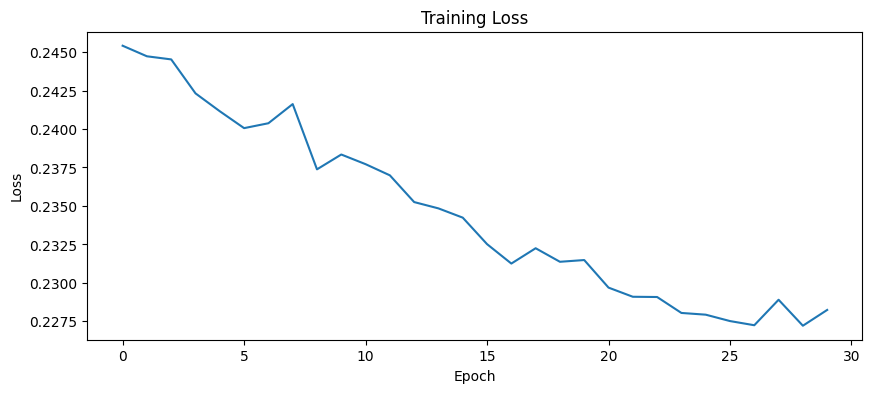

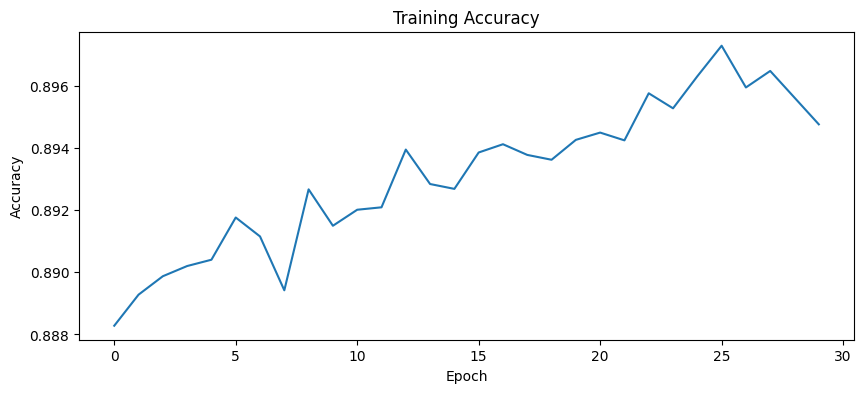

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

              precision    recall  f1-score   support

           0       0.80      0.92      0.85      9885
           1       0.90      0.77      0.83     10115

    accuracy                           0.84     20000
   macro avg       0.85      0.85      0.84     20000
weighted avg       0.85      0.84      0.84     20000



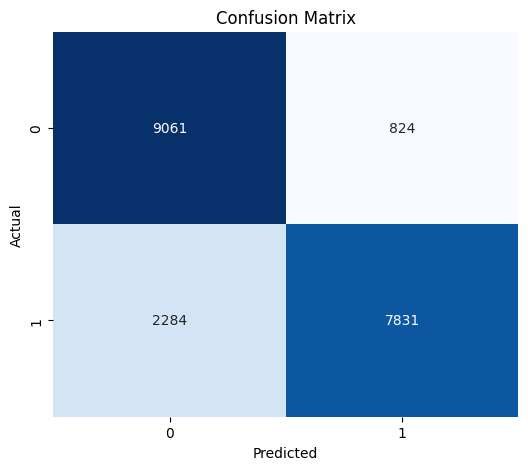

In [113]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.numpy())

print(classification_report(y_true, y_pred))

cm=confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [114]:
import optuna
import torch.nn as nn

def create_model(input_dim, num_classes, n_layers, n_neurons):
    layers = []
    in_features = input_dim

    for _ in range(n_layers):
        layers.append(nn.Linear(in_features, n_neurons))
        layers.append(nn.ReLU())
        in_features = n_neurons

    layers.append(nn.Linear(in_features, num_classes))
    return nn.Sequential(*layers)


def objective(trial):

    # hiperparámetros a tunear
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    n_layers = trial.suggest_int("n_layers", 1, 4)
    n_neurons = trial.suggest_int("n_neurons", 16, 256)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    train_loader_hp = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model_hp = create_model(input_dim, num_classes, n_layers, n_neurons)
    optimizer = torch.optim.Adam(model_hp.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model_hp.train()
    for epoch in range(5):  # entrenamos poco para no tardar horas
        for X_batch, y_batch in train_loader_hp:
            optimizer.zero_grad()
            outputs = model_hp(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    # evaluación rápida
    model_hp.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            outputs = model_hp(Xb)
            _, preds = outputs.max(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    accuracy = correct / total
    return accuracy


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)


[I 2025-12-06 20:11:23,908] A new study created in memory with name: no-name-a78c80e2-fd71-44d0-8c03-fb2547b60dbe
[I 2025-12-06 20:11:45,074] Trial 0 finished with value: 0.86955 and parameters: {'lr': 0.006614782821340956, 'n_layers': 3, 'n_neurons': 57, 'batch_size': 32}. Best is trial 0 with value: 0.86955.
[I 2025-12-06 20:12:04,301] Trial 1 finished with value: 0.85995 and parameters: {'lr': 0.015648197355949817, 'n_layers': 2, 'n_neurons': 76, 'batch_size': 32}. Best is trial 0 with value: 0.86955.
[I 2025-12-06 20:12:11,623] Trial 2 finished with value: 0.8709 and parameters: {'lr': 0.0044323682077297725, 'n_layers': 1, 'n_neurons': 195, 'batch_size': 128}. Best is trial 2 with value: 0.8709.
[I 2025-12-06 20:12:24,573] Trial 3 finished with value: 0.87075 and parameters: {'lr': 0.002011841512601363, 'n_layers': 2, 'n_neurons': 137, 'batch_size': 64}. Best is trial 2 with value: 0.8709.
[I 2025-12-06 20:12:31,150] Trial 4 finished with value: 0.86485 and parameters: {'lr': 0.000

In [115]:
print("Best accuracy:", study.best_value)
print("Best params:", study.best_params)

Best accuracy: 0.87315
Best params: {'lr': 0.0020336292098318627, 'n_layers': 3, 'n_neurons': 143, 'batch_size': 64}


In [116]:
best = study.best_params

final_model = create_model(
    input_dim,
    num_classes,
    best["n_layers"],
    best["n_neurons"]
)

optimizer = torch.optim.Adam(final_model.parameters(), lr=best["lr"])

In [117]:
optimizer = torch.optim.Adam(final_model.parameters(), lr=best["lr"])
criterion = nn.CrossEntropyLoss()

In [118]:
final_train_loader = DataLoader(train_dataset, batch_size=best["batch_size"], shuffle=True)

In [119]:
num_epochs = 30
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    final_model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in final_train_loader:
        optimizer.zero_grad()
        outputs = final_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        _, preds = outputs.max(1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_losses.append(epoch_loss / len(final_train_loader))
    train_accuracies.append(correct / total)

    print(f"Epoch {epoch+1}: Loss={train_losses[-1]:.4f}, Acc={train_accuracies[-1]:.4f}")


Epoch 1: Loss=0.3200, Acc=0.8544
Epoch 2: Loss=0.2913, Acc=0.8695
Epoch 3: Loss=0.2816, Acc=0.8731
Epoch 4: Loss=0.2760, Acc=0.8765
Epoch 5: Loss=0.2704, Acc=0.8783
Epoch 6: Loss=0.2649, Acc=0.8816
Epoch 7: Loss=0.2590, Acc=0.8839
Epoch 8: Loss=0.2527, Acc=0.8874
Epoch 9: Loss=0.2447, Acc=0.8903
Epoch 10: Loss=0.2390, Acc=0.8938
Epoch 11: Loss=0.2313, Acc=0.8972
Epoch 12: Loss=0.2238, Acc=0.9006
Epoch 13: Loss=0.2161, Acc=0.9043
Epoch 14: Loss=0.2098, Acc=0.9080
Epoch 15: Loss=0.2023, Acc=0.9116
Epoch 16: Loss=0.1949, Acc=0.9151
Epoch 17: Loss=0.1876, Acc=0.9185
Epoch 18: Loss=0.1795, Acc=0.9218
Epoch 19: Loss=0.1742, Acc=0.9245
Epoch 20: Loss=0.1664, Acc=0.9281
Epoch 21: Loss=0.1607, Acc=0.9306
Epoch 22: Loss=0.1540, Acc=0.9339
Epoch 23: Loss=0.1497, Acc=0.9349
Epoch 24: Loss=0.1416, Acc=0.9407
Epoch 25: Loss=0.1380, Acc=0.9409
Epoch 26: Loss=0.1318, Acc=0.9445
Epoch 27: Loss=0.1290, Acc=0.9454
Epoch 28: Loss=0.1235, Acc=0.9478
Epoch 29: Loss=0.1178, Acc=0.9505
Epoch 30: Loss=0.1155, 

In [120]:
final_model.eval()
all_preds = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = final_model(X_batch)
        _, preds = outputs.max(1)
        all_preds.append(preds)

all_preds = torch.cat(all_preds)

In [121]:
print(classification_report(y_test, all_preds))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      9885
           1       0.87      0.83      0.85     10115

    accuracy                           0.85     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.85      0.85      0.85     20000



# Conclusion

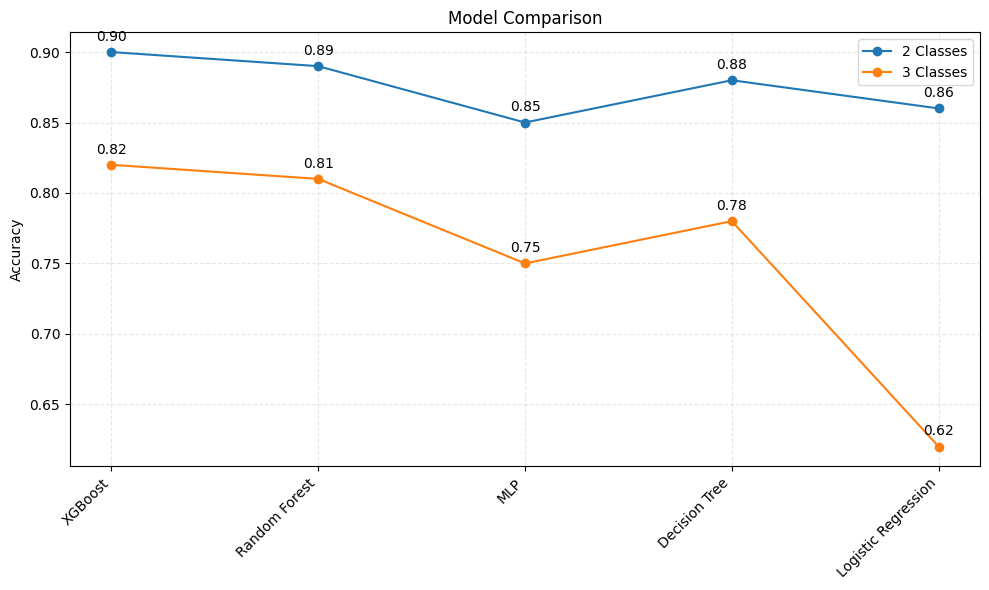

In [137]:
import matplotlib.pyplot as plt
import pandas as pd

models = ["XGBoost", "Random Forest", "MLP", "Decision Tree", "Logistic Regression"]
acc_2 = [0.90, 0.89, 0.85, 0.88, 0.86]
acc_3 = [0.82, 0.81, 0.75, 0.78, 0.62]

df = pd.DataFrame({
    "Model": models,
    "2 Classes": acc_2,
    "3 Classes": acc_3
})

plt.figure(figsize=(10,6))

plt.plot(df["Model"], df["2 Classes"], marker="o", label="2 Classes")
plt.plot(df["Model"], df["3 Classes"], marker="o", label="3 Classes")

plt.grid(alpha=0.3, linestyle='--')

for i, v in enumerate(acc_2):
    plt.annotate(f"{v:.2f}", (i, v), textcoords="offset points", xytext=(0,8), ha='center')

for i, v in enumerate(acc_3):
    if v is not None:
        plt.annotate(f"{v:.2f}", (i, v), textcoords="offset points", xytext=(0,8), ha='center')

plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.legend()

plt.tight_layout()
plt.show()

Among the tested models, XGBoost achieved the best performance for both 2-class and 3-class classifications (0.90 and 0.82), closely followed by Random Forest. Ensemble models proved to be more stable when facing the increased complexity of the problem, while simpler models, such as Logistic Regression, showed a more significant drop in performance. Overall, tree-based models are the most suitable for risk classification, offering better results and greater consistency across both scenarios

Although the binary classification shows higher accuracy, it oversimplifies the phenomenon and loses essential clinical information. The 3-class model is more aligned with medical practice, allows for more granular decisions, and reduces critical underdiagnosis errors. In health risk contexts, clinical utility outweighs standalone accuracy